In [51]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(33)

## Constants & Parameters

In [52]:
# PHYSICAl CONSTANTS

M_E_SI = 9.1093837015e-31 # electron mass in kg
M_E = 0.511 # electron mass in MeV/c^2
Q_E_SI = -1.602176634e-19 # electron charge in C
Q_E = -1. # electron charge in e
EPSILON_0 = 5.5263494e13  # vacuum permittivity in in e/(MV*m)
C = 299792458 # speed of light in m/s


# HYPERPARAMETERS

LENGTH_PRIOR = 0.5 # length of prior region to be modeled in m
LENGTH_D = 0.25 # length of drift chamber in m
LENGTH_E = 3.75 # length of electric field chamber in m
LENGTH_POSTERIOR = 2.5 # length of posterior region to be modeled in m


ENERGY_0 = 1e-2 # initial kinetic energy of reference particle in MeV


SIGMA_Z = 0.1 # standard deviation of initial z position in m

SIGMA_PZ_BG = 1e-2 # standard deviation of initial z momentum in 1 (betagamma)


E_Z = -1. # electric field strength in MV/m

N_PARTICLES = int(1e2) # number of macro particles
TOTAL_CHARGE_SI = -1e-9 # total bunch charge in C

DELTA_POS = 1e-3  # spacing of z-grid (Fields, Space Charge, etc.) in m
DELTA_T = 2e-12 # time step in s    CFL-Condition: DELTA_T < DELTA_POS / C
T_MAX = 1e-7 # maximum simulation time in s


# DERIVED QUANTITIES

Z_START = -LENGTH_PRIOR # start of model space
Z_0 = Z_START + LENGTH_PRIOR # initial z position of particles
Z_1 = Z_START + LENGTH_PRIOR + LENGTH_D # z position of end of drift chamber = start of electric field chamber
Z_2 = Z_START + LENGTH_PRIOR + LENGTH_D + LENGTH_E # z position of end of electric field chamber
Z_END = Z_2 + LENGTH_POSTERIOR # end of model space

GAMMA_0 = (ENERGY_0 + M_E) / M_E # initial Lorentz factor of reference particle
BETA_0 = np.sqrt(1 - 1 / GAMMA_0**2) # initial beta of reference particle
PZ_0 = BETA_0 * GAMMA_0 * M_E # initial momentum of reference particle in MeV/c

POSITION_0 = Z_0 # initial position of particles in m
MOMENTUM_0 = PZ_0 # initial momentum in MeV/c

BG_to_P = lambda bg: bg * M_E # function to transform momentum from betagamma to particle units

POSITION_SIGMA = SIGMA_Z # in m
MOMENTUM_SIGMA = BG_to_P(SIGMA_PZ_BG) # in MeV/c


N_REAL_PARTICLES = np.abs(TOTAL_CHARGE_SI / Q_E_SI) # number of real electrons in the bunch
MACRO_WEIGHT = N_REAL_PARTICLES / N_PARTICLES 

M_MACRO = M_E * MACRO_WEIGHT
Q_MACRO = Q_E * MACRO_WEIGHT

assert DELTA_T < DELTA_POS / C, "CFL condition violated: DELTA_T must be less than DELTA_POS / C"

## Phyiscs Helper

In [ ]:
def p_to_betagamma(p):
    '''
    Transform momentum from particle units [MeV/c] to dimensionless beta*gamma unit [1]
    '''

    return p / M_E

def betagamma_to_p(betagamma):
    '''
    Transform momentum from dimensionless beta*gamma unit [1] to particle units [MeV/c]
    '''

    return betagamma * M_E

## Plotting Helper

In [53]:
Z_GRID = np.arange(Z_START, Z_END + DELTA_POS, DELTA_POS)
N_Z = len(Z_GRID)
POSITION_GRID = Z_GRID

def PLOT_particles(positions, momenta, title="Particle Distribution"):
    plt.figure(figsize=(10, 6))
    plt.scatter(positions, momenta, alpha=0.5)
    plt.title(title)
    plt.xlabel('z [m]')
    plt.ylabel('p_z [MeV/c]')
    plt.grid()
    plt.show()

def PLOT_rho(space_grid, rho_grid):
    plt.figure(figsize=(10, 6))
    plt.plot(space_grid, rho_grid)
    plt.title('Charge Density')
    plt.xlabel('z [m]')
    plt.ylabel('rho [e/m^3]')
    plt.grid()
    plt.show()

## Solver Helper

![image-2.png](attachment:image-2.png)
![image.png](attachment:image.png)
![image-7.png](attachment:image-7.png)
![image-3.png](attachment:image-3.png)
![image-4.png](attachment:image-4.png)
![image-5.png](attachment:image-5.png)
![image-6.png](attachment:image-6.png)

In [54]:
import scipy.fft

def gather_field(position_particles, E_grid):
    ''' 
    Interpolate electric field values from grid to particle positions
    '''

    E_particles = np.interp(position_particles, POSITION_GRID, E_grid)
    
    return E_particles
    

def scatter_charge(position_particles):
    '''
    Calculate charge density on grid from particle positions
    '''

    # Distribute particle charge to nearest grid points linearly
    j = np.floor((position_particles - Z_START) / DELTA_POS).astype(int)
    frac_j = (position_particles - Z_START - j * DELTA_POS) / DELTA_POS
    frac_j_1 = 1.0 - frac_j

    assert np.all(j >= 0) and np.all(j < N_Z - 1) # TODO handle out of bound particles

    # Sum up contributions to each grid point, extended to N_Z length even if no contribution there
    rho = np.bincount(j, weights=frac_j_1 * Q_MACRO, minlength= N_Z) + \
          np.bincount(j + 1, weights=frac_j * Q_MACRO, minlength= N_Z)     

    volume_cell = DELTA_POS * 1.0 * 1.0
    rho_grid = rho / volume_cell
    
    return rho_grid

def solve_E_int(rho_grid):
    ''' 
    Solve for internal electric field grid from charge density grid
    '''

    # Using discrete sine transform for E=0 at boundaries, we dont want periodic BCs
    rho_freq = scipy.fft.dst(rho_grid, type=1) # type 1 means indices -1 and N are zero
    length = (N_Z + 1) * DELTA_POS # total length of chamber +1, as boundary (= zero) points lie outside of grid
    k_freq = np.pi * np.arange(1, N_Z + 1) / length  # Without factor 2 (!)
    
    phi_freq = rho_freq / (EPSILON_0 * k_freq**2) # solve Poisson's equation

    phi_grid = scipy.fft.idst(phi_freq, type=1) # inverse transform

    E_grid = -np.gradient(phi_grid, DELTA_POS) 

    return E_grid

def solve_E_tot(rho_grid):
    '''
    Calculate total electric field grid
    '''

    E_int_grid = solve_E_int(rho_grid)

    E_ext_grid = np.zeros_like(rho_grid)
    E_ext_grid[(POSITION_GRID >= Z_1) & (POSITION_GRID <= Z_2)] = E_Z 

    E_tot_grid = E_int_grid + E_ext_grid

    return E_tot_grid
        
def velocity_particles_SI(momentum_particles):
    '''
    Calculate particle velocity from momentum using relativistic formula
    '''
    gamma = np.sqrt(1 + (momentum_particles / M_E)**2)
    velocity_particles = (momentum_particles / (gamma * M_E)) * C # convert from MeV/c to m/s
    return velocity_particles


def push_particles(position_particles, momentum_stag_particles, E_particles):
    '''
    Update particle positions and momenta based on electric field
    '''

    # Using Velocity Verlet integration for better accuracy and stability

    next_momentum_stag_particles = momentum_stag_particles + Q_E * E_particles * (C*DELTA_T)
    next_velocity_stag_particles = velocity_particles_SI(next_momentum_stag_particles)
    next_position_particles = position_particles + next_velocity_stag_particles * DELTA_T

    return next_position_particles, next_momentum_stag_particles


    

## Initialization

In [55]:
position_particles = np.random.normal(POSITION_0, POSITION_SIGMA, N_PARTICLES)
momentum_particles = np.random.normal(MOMENTUM_0, MOMENTUM_SIGMA, N_PARTICLES)

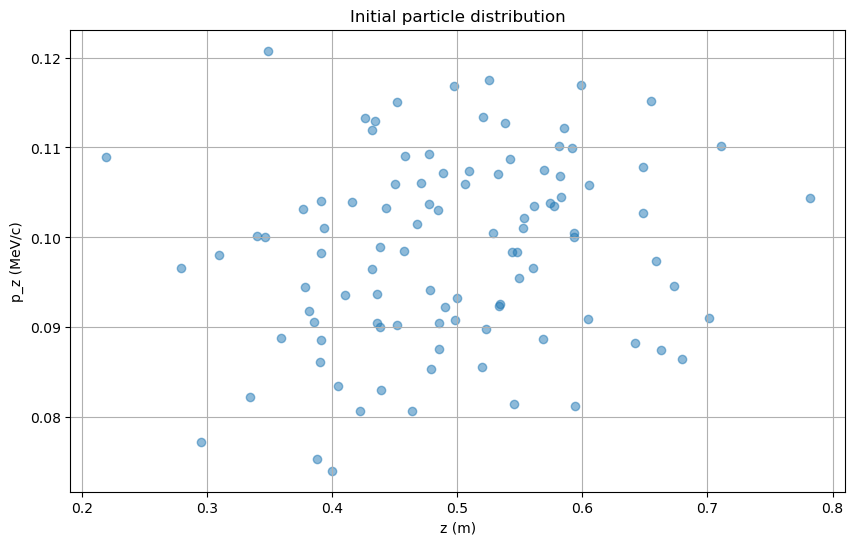

In [56]:
PLOT_particles(position_particles, momentum_particles, 'Initial particle distribution')

## INTEGRATION LOOP

In [57]:
# Initialize staggered Momentum 

rho_grid = scatter_charge(position_particles)
E_tot_grid = solve_E_tot(rho_grid) 
E_particles = gather_field(position_particles, E_tot_grid)

momentum_stag_particles = momentum_particles - Q_E * E_particles * (C*DELTA_T) / 2 # staggered momentum for Velocity Verlet

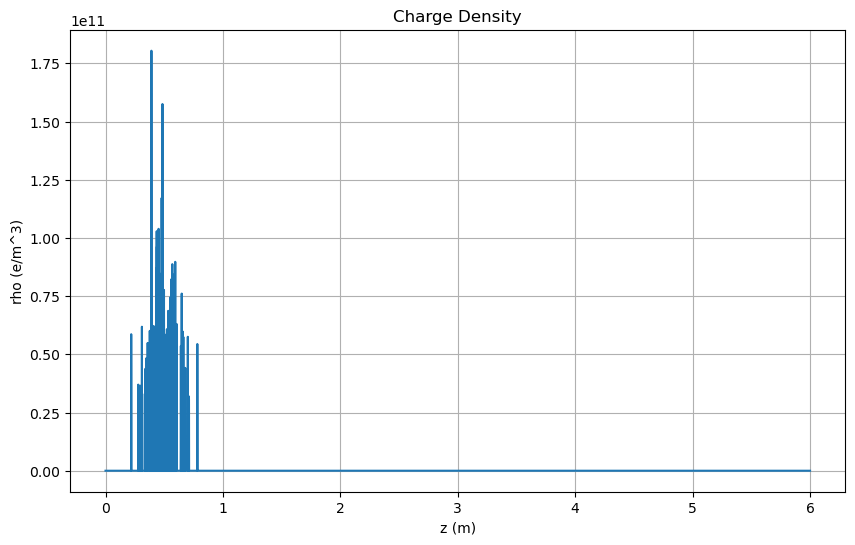

In [58]:
PLOT_rho(POSITION_GRID, rho_grid)

In [59]:
# Main integration loop

nums_particles = [N_PARTICLES]
times = [0.]
position_means = [np.mean(position_particles)]
momentum_stag_means = [np.mean(momentum_stag_particles)]
position_sigmas = [np.std(position_particles)]
momentum_stag_sigmas = [np.std(momentum_stag_particles)]

z_mean = position_means[-1]
t = 0.
while z_mean < Z_2 and t < T_MAX:

    rho_grid = scatter_charge(position_particles)
    E_tot_grid = solve_E_tot(rho_grid)
    E_particles = gather_field(position_particles, E_tot_grid)

    position_particles, momentum_stag_particles = push_particles(
        position_particles, 
        momentum_stag_particles, 
        E_particles
    )

    # Handle lost particles
    valid_mask = (position_particles >= Z_START) & (position_particles < Z_END)
    position_particles = position_particles[valid_mask]
    momentum_stag_particles = momentum_stag_particles[valid_mask]
    current_num_particles = len(position_particles)


    times.append(t)
    position_means.append(np.mean(position_particles))
    momentum_stag_means.append(np.mean(momentum_stag_particles))
    position_sigmas.append(np.std(position_particles))
    momentum_stag_sigmas.append(np.std(momentum_stag_particles))


    nums_particles.append(current_num_particles)
    z_mean = position_means[-1]
    t += DELTA_T 


## PLOTTING

In [60]:
times = np.array(times)
times_stag = times - DELTA_T / 2
position_means = np.array(position_means)
momentum_stag_means = np.array(momentum_stag_means)
position_sigmas = np.array(position_sigmas)
momentum_stag_sigmas = np.array(momentum_stag_sigmas)

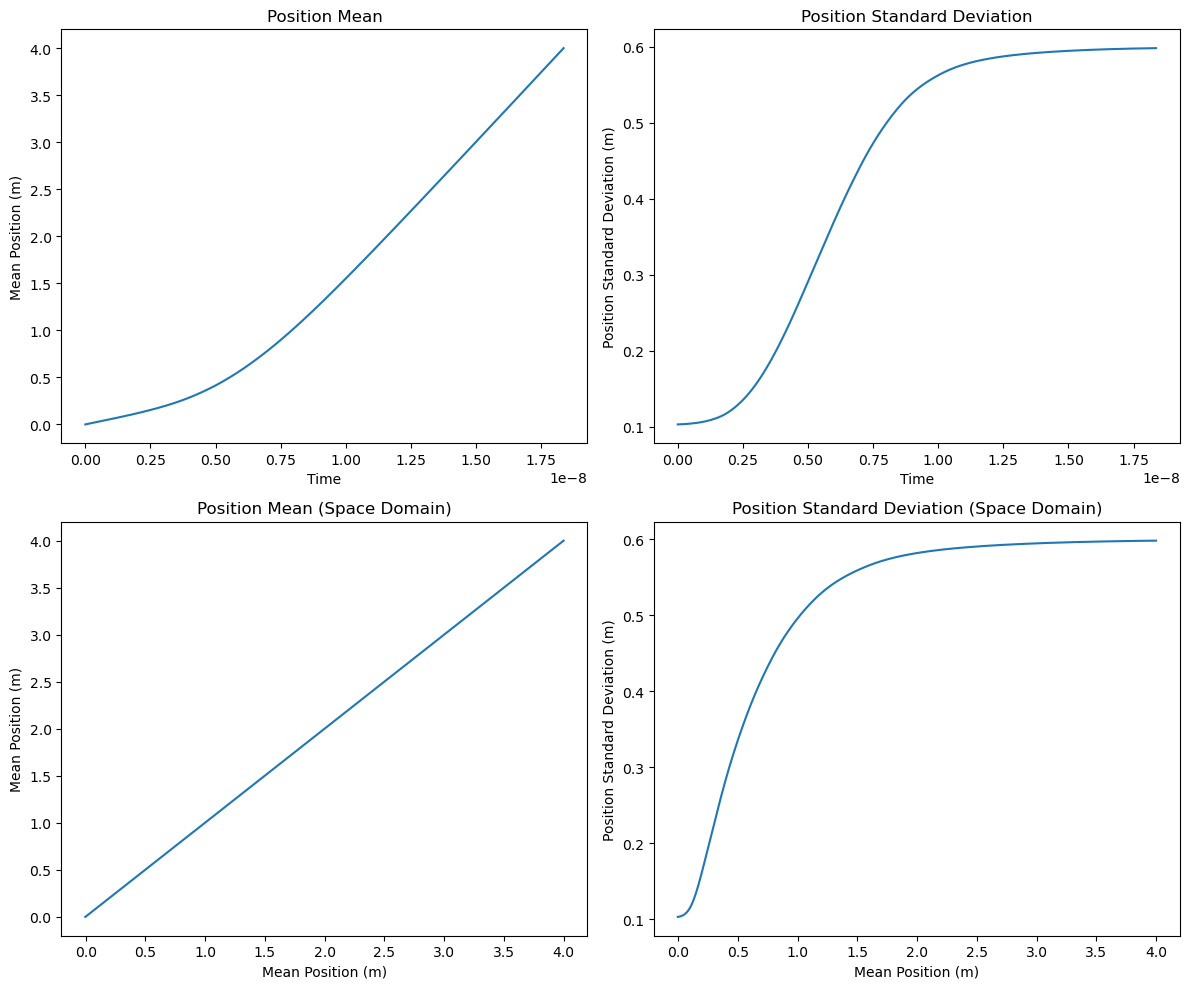

In [66]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

axes[0, 0].plot(times, position_means, color='orange')
axes[0, 0].set_xlabel('time [s]')
axes[0, 0].set_ylabel('mean(z) [m]')
axes[0, 0].set_title('mean(z) vs time')

axes[0, 1].plot(times, position_sigmas, color='orange')
axes[0, 1].set_xlabel('time [s]')
axes[0, 1].set_ylabel('rms(z) [m]')
axes[0, 1].set_title('rms(z) vs time')

axes[1, 0].plot(position_means, position_means)
axes[1, 0].set_xlabel('mean(z) [m]')
axes[1, 0].set_ylabel('mean(z) [m]')
axes[1, 0].set_title('mean(z) vs z')

axes[1, 1].plot(position_means, position_sigmas)
axes[1, 1].set_xlabel('mean(z) [m]')
axes[1, 1].set_ylabel('rms(z) [m]')
axes[1, 1].set_title('rms(z) vs z')

fig.tight_layout()
plt.show()

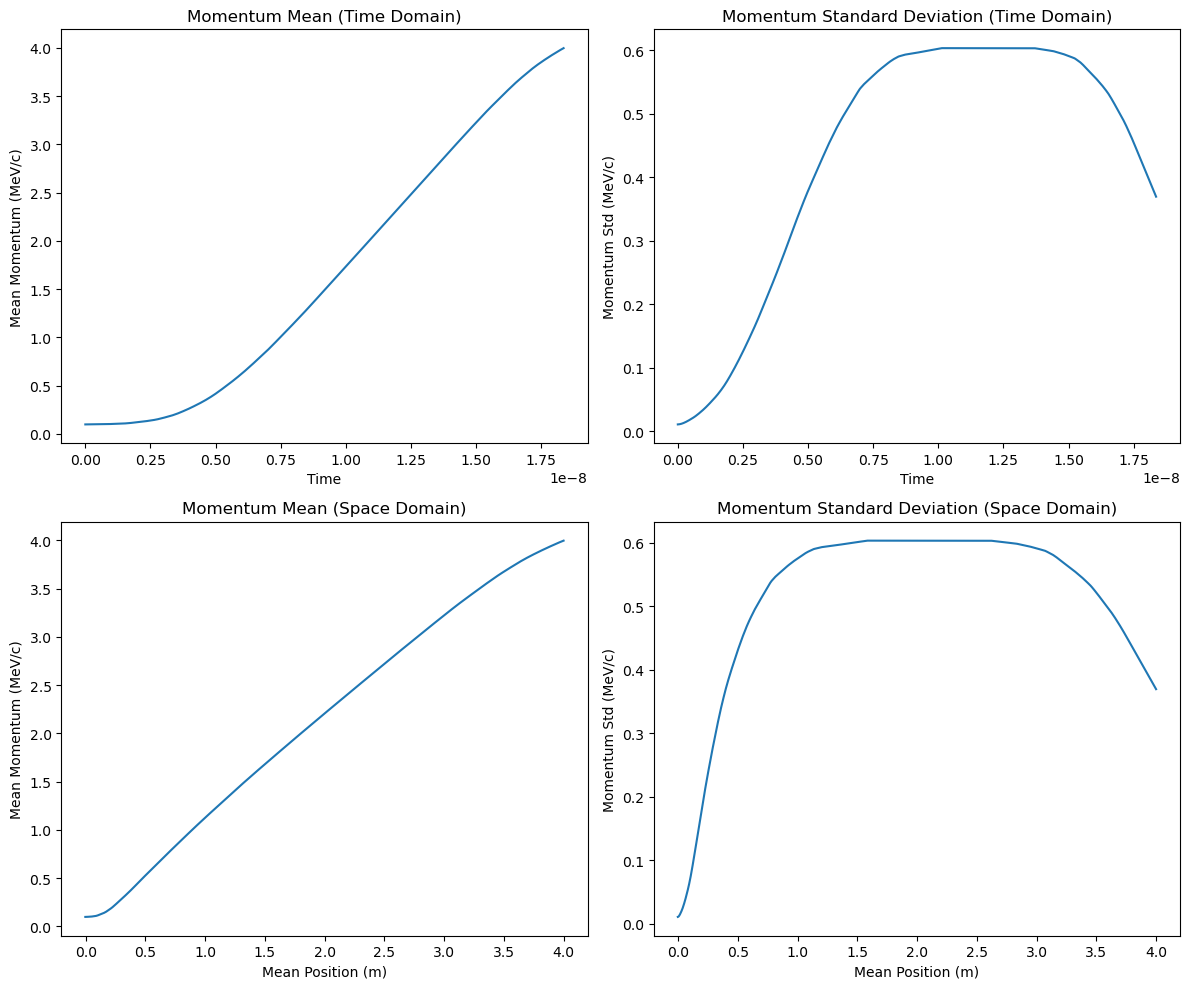

In [67]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

axes[0, 0].plot(times_stag, p_to_betagamma(momentum_stag_means), color='orange')
axes[0, 0].set_xlabel('time [s]')
axes[0, 0].set_ylabel('mean(pz) [1]')
axes[0, 0].set_title('mean(pz) vs time')

axes[0, 1].plot(times_stag, p_to_betagamma(momentum_stag_sigmas), color='orange')
axes[0, 1].set_xlabel('time [s]')
axes[0, 1].set_ylabel('rms(pz) [1]')
axes[0, 1].set_title('rms(pz) vs time')

momentum_means_interp = np.interp(times, times_stag, momentum_stag_means)
momentum_sigmas_interp = np.interp(times, times_stag, momentum_stag_sigmas)

axes[1, 0].plot(position_means, p_to_betagamma(momentum_means_interp))
axes[1, 0].set_xlabel('mean(z) [m]')
axes[1, 0].set_ylabel('mean(pz) [1]')
axes[1, 0].set_title('mean(pz) vs z')

axes[1, 1].plot(position_means, p_to_betagamma(momentum_sigmas_interp))
axes[1, 1].set_xlabel('mean(z) [m]')
axes[1, 1].set_ylabel('rms(pz) [1]')
axes[1, 1].set_title('rms(pz) vs z')

fig.tight_layout()
plt.show()

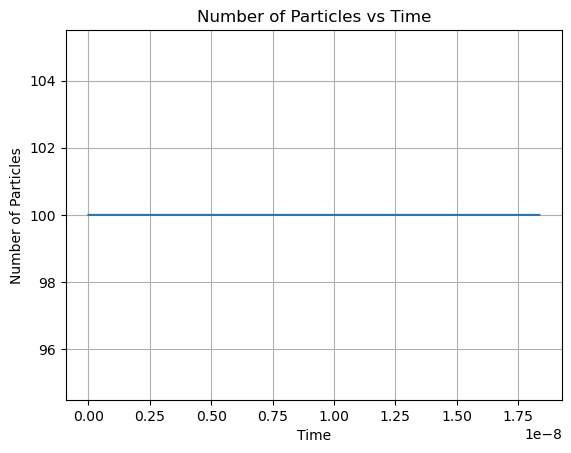

In [68]:
plt.plot(times, nums_particles)
plt.xlabel('Time')
plt.ylabel('Number of Particles')
plt.title('Number of Particles vs Time')
plt.grid()

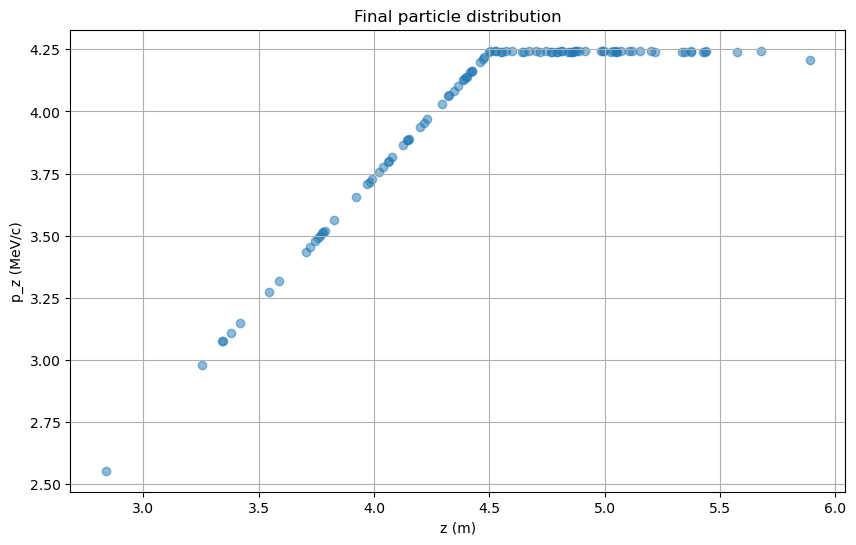

In [69]:
PLOT_particles(position_particles, momentum_stag_particles, 'Final particle distribution')

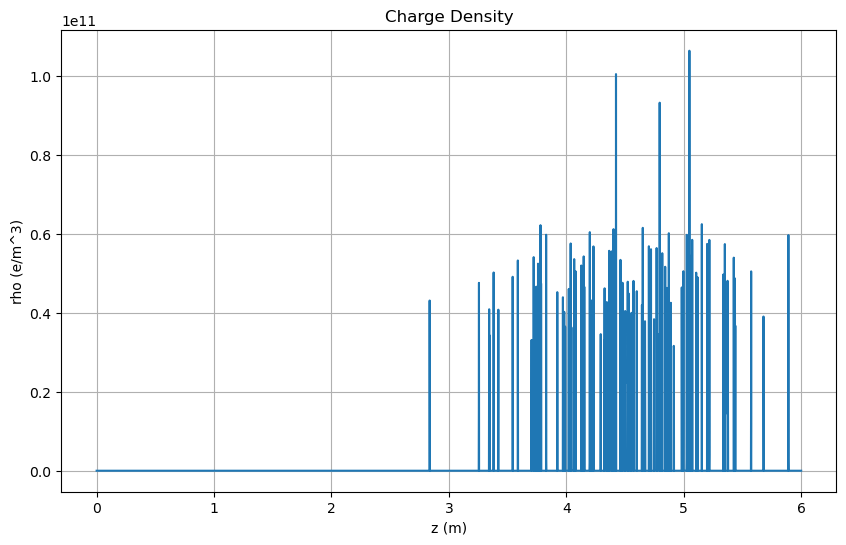

In [70]:
PLOT_rho(POSITION_GRID, rho_grid)